In [3]:
import pandas as pd
import numpy as np

In [40]:
df=pd.read_csv('/content/powerplant_data.csv')

In [41]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


AT-temperature
v-vaccum
AP-Pressure
RH-Humidity
PE-Energy output

In [42]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [43]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [44]:
y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


In [45]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [46]:
df.shape

(9568, 5)

In [47]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [60]:
import torch
import torch.nn as nn
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [61]:
type(X_train_tensor)

torch.Tensor

In [62]:
type(X_train_scaled)

numpy.ndarray

In [63]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)


In [64]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [65]:
train_loader.dataset.tensors[0].shape

torch.Size([7654, 4])

In [66]:
class ANN(nn.Module):
  def __init__(self):
    super(ANN,self).__init__()
    self.model=nn.Sequential(
        nn.Linear(X_train.shape[1],6),
        nn.ReLU(),
        nn.Linear(6,6),
        nn.ReLU(),
        nn.Linear(6,1)
    )
  def forward(self,x):
    return self.model(x)

In [67]:
model=ANN()

In [ ]:
import torch.optim as optim
#loss and optimizer
crietrion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())




train_losses=[]
val_losses=[]

best_val_loss=float('inf')

epochs=100
for epoch in range(epochs):
  model.train()
  running_loss=0.0

  for xb,yb in train_loader:
    optimizer.zero_grad()#reset grad

    output=model(xb)
    loss=crietrion(output,yb) #compute loss
    loss.backward()#calculate grad
    optimizer.step()#update parameter

    running_loss+=loss.item()#convert tensor to python float

  epoch_train_loss=running_loss/len(train_loader)
  train_losses.append(epoch_train_loss)

  running_val_loss=0.0
  model.eval()
  with torch.no_grad():
    for xb,yb in test_loader:
        output=model(xb)
        loss=crietrion(output,yb)
        running_val_loss+=loss.item()
  epoch_test_loss=running_val_loss/len(test_loader)
  val_losses.append(epoch_test_loss)
  print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_train_loss:.4f}, Test Loss: {epoch_test_loss:.4f}")

  if epoch_test_loss<best_val_loss:
    best_val_loss=epoch_test_loss
    torch.save(model.state_dict(),"best_model.pth")




In [69]:


train_losses=[]
val_losses=[]

best_val_loss=float('inf')

epochs=100
for epoch in range(epochs):
  model.train()
  running_loss=0.0

  for xb,yb in train_loader:
    optimizer.zero_grad()#reset grad

    output=model(xb)
    loss=crietrion(output,yb) #compute loss
    loss.backward()#calculate grad
    optimizer.step()#update parameter

    running_loss+=loss.item()#convert tensor to python float

  epoch_train_loss=running_loss/len(train_loader)
  train_losses.append(epoch_train_loss)

  running_val_loss=0.0
  model.eval()
  with torch.no_grad():
    for xb,yb in test_loader:
        output=model(xb)
        loss=crietrion(output,yb)
        running_val_loss+=loss.item()
  epoch_test_loss=running_val_loss/len(test_loader)
  val_losses.append(epoch_test_loss)
  print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_train_loss:.4f}, Test Loss: {epoch_test_loss:.4f}")

  if epoch_test_loss<best_val_loss:
    best_val_loss=epoch_test_loss
    torch.save(model.state_dict(),"best_model.pth")



Epoch 1/100, Train Loss: 205478.3947, Test Loss: 203037.4534
Epoch 2/100, Train Loss: 195286.1766, Test Loss: 182788.4792
Epoch 3/100, Train Loss: 160818.2898, Test Loss: 135326.1111
Epoch 4/100, Train Loss: 111110.6184, Test Loss: 89708.3701
Epoch 5/100, Train Loss: 75580.3223, Test Loss: 62572.8493
Epoch 6/100, Train Loss: 51950.5744, Test Loss: 40550.6736
Epoch 7/100, Train Loss: 31164.5489, Test Loss: 21606.9850
Epoch 8/100, Train Loss: 15388.7172, Test Loss: 10009.6277
Epoch 9/100, Train Loss: 7672.4662, Test Loss: 5633.3267
Epoch 10/100, Train Loss: 4904.3217, Test Loss: 3897.9331
Epoch 11/100, Train Loss: 3485.2968, Test Loss: 2823.0731
Epoch 12/100, Train Loss: 2560.4605, Test Loss: 2116.5486
Epoch 13/100, Train Loss: 1953.9441, Test Loss: 1644.1296
Epoch 14/100, Train Loss: 1547.2588, Test Loss: 1311.1450
Epoch 15/100, Train Loss: 1250.1705, Test Loss: 1059.8337
Epoch 16/100, Train Loss: 1015.1316, Test Loss: 860.9455
Epoch 17/100, Train Loss: 823.4347, Test Loss: 698.5597
Epo

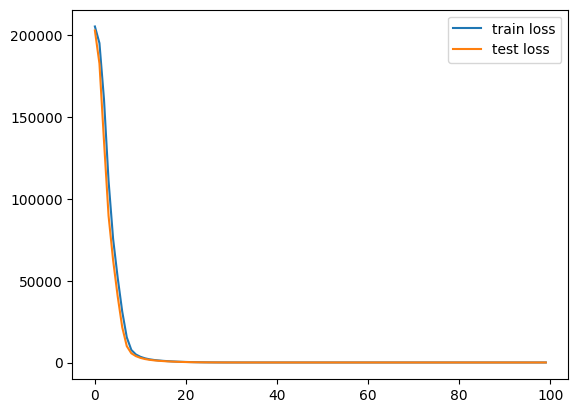

In [70]:
import matplotlib.pyplot as plt
plt.plot(train_losses,label="train loss")
plt.plot(val_losses,label="test loss")
plt.legend()

In [71]:
#loading the best model
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [73]:
#evaluation
with torch.no_grad():
  model.eval()
  train_pred=model(X_train_tensor)
  test_pred=model(X_test_tensor)

  train_mse_loss=crietrion(train_pred,y_train_tensor)
  test_mse_loss=crietrion(test_pred,y_test_tensor)

print("Traing mse loss",train_mse_loss)
print("Test mse loss",test_mse_loss)



Traing mse loss tensor(18.9914)
Test mse loss tensor(17.3861)


In [75]:
from sklearn.metrics import r2_score
print("r2 score",r2_score(y_test,test_pred))

r2 score 0.9392400202452118


In [76]:
predicted_df=pd.DataFrame(test_pred.numpy(),columns=["Predicted"])
actual_df=pd.DataFrame(y_test.values,columns=["Actual"])
pd.concat([actual_df,predicted_df],axis=1)

,Actual,Predicted
0,433.27,436.568298
1,438.16,436.712769
2,458.42,459.915802
3,480.82,476.266724
4,441.41,438.641022
...,...,...
1909,456.70,450.684937
1910,438.04,433.912445
1911,467.80,467.492035
1912,437.14,433.423553
